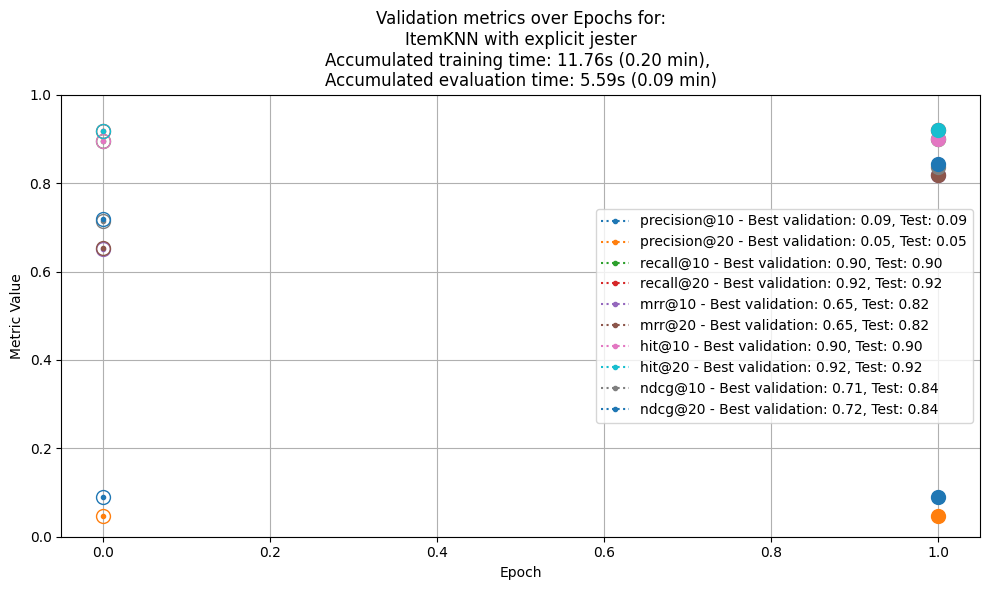

In [2]:
import re
import matplotlib.pyplot as plt
models = ['ItemKNN', 'BPR', 'NeuMF', 'GCMC']
datasets = ['ml-100k', 'jester', 'amazon_all_beauty', 'netflix']
datatypes = ['explicit', 'implicit']  
model = models[0]         # <-- change as needed
dataset = datasets[1]     # <-- change as needed
datatype = datatypes[0]   # <-- change as needed
log_file = f"data/log/{model}--{dataset}--{datatype}.txt"  

training_data = {} # To store metric values
test_data = {} # To store test result summary

train_time = 0.0 # To store accumulated training time (in seconds)
eval_time = 0.0 # To store accumulated eval time (in seconds)

with open(log_file, "r") as f:
    for line in f:
        # Extracting per-epoch metrics (mrr@10, recall@10, precision@10, etc.)
        metric_pattern = r"(\w+@\d+)\s*:\s*([\d.]+)"
        matches = re.findall(metric_pattern, line)
        for metric, value in matches:
            if metric not in training_data:
                training_data[metric] = []
            training_data[metric].append(float(value))

        # Match summary lines containing test results
        if "INFO  test result:" in line:
            test_data = {m[0]: float(m[1]) for m in re.findall(r"\('([^']+)', np\.float64\(([\d.]+)\)\)", line)}

        # Accumulate training and evaluation time from epoch logs
        m_train = re.search(r"epoch\s+(\d+)\s+training\s+\[time:\s*([\d.]+)s", line)
        if m_train:
            train_time += float(m_train.group(2))

        m_eval = re.search(r"epoch\s+(\d+)\s+evaluating\s+\[time:\s*([\d.]+)s", line)
        if m_eval:
            eval_time += float(m_eval.group(2))

num_epochs = len(next(iter(training_data.values())))  # Get the number of epochs
epochs = range(num_epochs)

# Define colors for each metric (up to 9 different)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:cyan', 'tab:gray']

# Plot
plt.figure(figsize=(10, 6))

# Loop through all metrics and plot them
for idx, metric in enumerate(training_data):
    max_x = max(range(len(training_data[metric])), key=lambda i: training_data[metric][i])
    plt.plot(epochs, training_data[metric], marker='.', linestyle=':', color=colors[idx % len(colors)], 
             label= f"{metric} - Best validation: {training_data[metric][max_x]:.2f}, Test: {test_data[metric]:.2f}")
    plt.plot(max_x, training_data[metric][max_x], marker='o', color=colors[idx % len(colors)], markersize=10, markerfacecolor='none', markeredgewidth=1)
    
    plt.plot(num_epochs, test_data[metric], marker='o', markersize=10, color=colors[idx % len(colors)])

time_print =    f"Accumulated training time: {train_time:.2f}s ({train_time/60:.2f} min),"\
                f" \n"\
                f"Accumulated evaluation time: {eval_time:.2f}s ({eval_time/60:.2f} min)"


plt.title(f"Validation metrics over Epochs for:\n" + 
          f"{model} with {datatype} {dataset}\n" +
          f"{time_print}")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)
plt.show()

In [2]:
# import re
# import matplotlib.pyplot as plt

# log_file = "data/log/NeuMF-ml-100k.txt"  # <-- change this if needed

# recall_values, mrr_values, ndcg_values, hit_values, precision_values = [], [], [], [], []
# test_result = {}

# with open(log_file, "r") as f:
#     for line in f:
#         recall_match = re.search(r"recall@10\s*:\s*([\d.]+)", line)
#         mrr_match = re.search(r"mrr@10\s*:\s*([\d.]+)", line)
#         ndcg_match = re.search(r"ndcg@10\s*:\s*([\d.]+)", line)
#         hit_match = re.search(r"hit@10\s*:\s*([\d.]+)", line)
#         precision_match = re.search(r"precision@10\s*:\s*([\d.]+)", line)
        
#         if recall_match: recall_values.append(float(recall_match.group(1)))
#         if mrr_match: mrr_values.append(float(mrr_match.group(1)))
#         if ndcg_match: ndcg_values.append(float(ndcg_match.group(1)))
#         if hit_match: hit_values.append(float(hit_match.group(1)))
#         if hit_match: precision_values.append(float(precision_match.group(1)))

#         # match summary lines
#         if "INFO  test result:" in line:
#             test_result = {m[0]: float(m[1]) for m in re.findall(r"\('([^']+)', np\.float64\(([\d.]+)\)\)", line)}

# # Make sure both lists are the same length
# #num_epochs = min(len(hit_values), len(ndcg_values), len(valid_scores))
# num_epochs = len(hit_values)
# epochs = range(num_epochs)

# def plot_metric(X, Y, marker, linestyle, color, label):
#     plt.plot(X, Y, marker=marker,linestyle=linestyle, color=color, label=label)
#     max_idx = max(range(len(Y)), key=lambda i: Y[i])
#     plt.plot(max_idx, Y[max_idx], marker='o', color=color, markersize=10, markerfacecolor='none', markeredgewidth=1)

# # Plot
# plt.figure(figsize=(10, 6))

# for metric, values, color in zip(
#     ['recall@10', 'mrr@10', 'ndcg@10', 'hit@10', 'precision@10'],
#     [recall_values, mrr_values, ndcg_values, hit_values, precision_values],
#     ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
# ):
#     plot_metric(epochs, values, marker='.',linestyle=':', color=color, label=metric)
#     if metric in test_result:
#         plt.plot(num_epochs, test_result[metric], marker='o', markersize=10,
#                  color=color)#, label=f"Test {metric}")

# # plot_metric(epochs, recall_values, marker='.',linestyle=':', color='tab:blue', label='recall@10')
# # plot_metric(epochs, mrr_values, marker='.', linestyle=':', color='tab:orange', label='mmr@10 (Valid_Score)')
# # plot_metric(epochs, ndcg_values, marker='.', linestyle=':', color='tab:green', label='ndgc@10')
# # plot_metric(epochs, hit_values, marker='.', linestyle=':', color='tab:red', label='hit@10')
# # plot_metric(epochs, precision_values, marker='.', linestyle=':', color='tab:purple', label='precision@10')

# plt.title("Validation metrics over Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Metric Value")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.ylim(0, 1)
# plt.show()